In [1]:
### 💡 Neden Kullanılır?
* **Güç Birliği:** Tek başına zayıf olan kararsız modelleri (decision stumps) birleştirerek yüksek doğrulukta güçlü bir model üretir.
* **Hata Avcısı:** Her adımda bir önceki modelin yaptığı hatalara odaklandığı için bias'ı (yanlılığı) hızla düşürür.
* **Kolaylık:** İnce ayar yapılması gereken (hyperparameter tuning) çok az parametresi vardır, kutudan çıktığı gibi iyi çalışır.

### 🎯 Ne Zaman / Ne İçin Kullanılır?
* **Düşük Varyans / Yüksek Bias Durumlarında:** Modeliniz veriyi öğrenmekte yetersiz kalıyorsa (underfitting), AdaBoost bu hatayı kapatmak için biçilmiş kaftandır.
* **Temiz ve Düşük Gürültülü Verilerde:** Veri setinizde çok fazla aykırı değer (outlier) veya etiket hatası **yoksa** tercih edilir. *(Çünkü hatalara aşırı odaklandığı için gürültülü veride kolayca overfitting olabilir).*
* **Hızlı Karar İstenen Canlı Sistemlerde:** Eğitilmesi biraz zaman alsa da, ayağa kaldırılan zayıf modeller çok küçük olduğu için tahmin (predict) aşaması inanılmaz hızlı çalışır.

SyntaxError: unterminated string literal (detected at line 3) (2721711598.py, line 3)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
df = pd.read_csv('16-diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.shape

(768, 9)

In [8]:
# diabetespedgreefunction ->  biriyin genetik oalrak diyabete yatkinligini gosterir bize  

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
# min kisimin hepsinde sifir olmasi sacma bunu bakicam 

In [12]:
df['Insulin'].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64

In [13]:
# arastirdigimda insulin degerinin 0 olmasi normal bir durum degilmis burada sikinti var muhtemelen

In [14]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [20]:
sifir_degerleri = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in sifir_degerleri:
    sifir_sayisi = (df[col]== 0).sum()
    print(sifir_sayisi)

5
35
227
374
11


In [21]:
# Bunlar muhtemelen kayim veriler bakicaz

In [22]:
# insulin kolonu normalde silmek mantikli olurdu cunku cok fazla vermiz kayip (sifir) ama insulin diyabette cok onemli bir rol oynadigi icin dolduracam 

In [19]:
# genele olaraak neler yapicagima kara verdim biraz eda yapip modelimi egitirken gerekli duzenlemeleri yapicam

In [23]:
sns.countplot(x='Outcome', data=df)
print(df['Outcome'].value_counts(normalize=True))

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


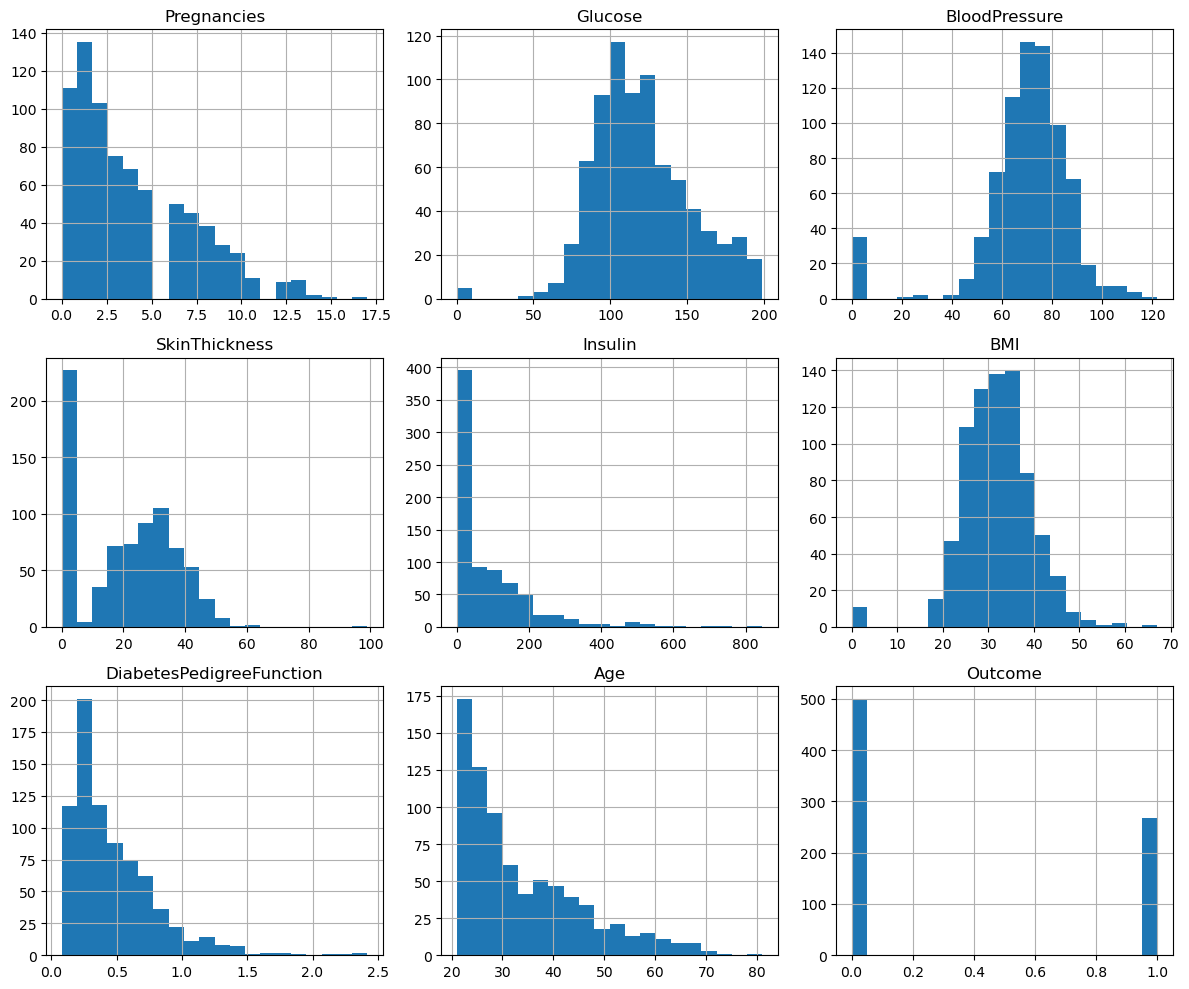

In [25]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

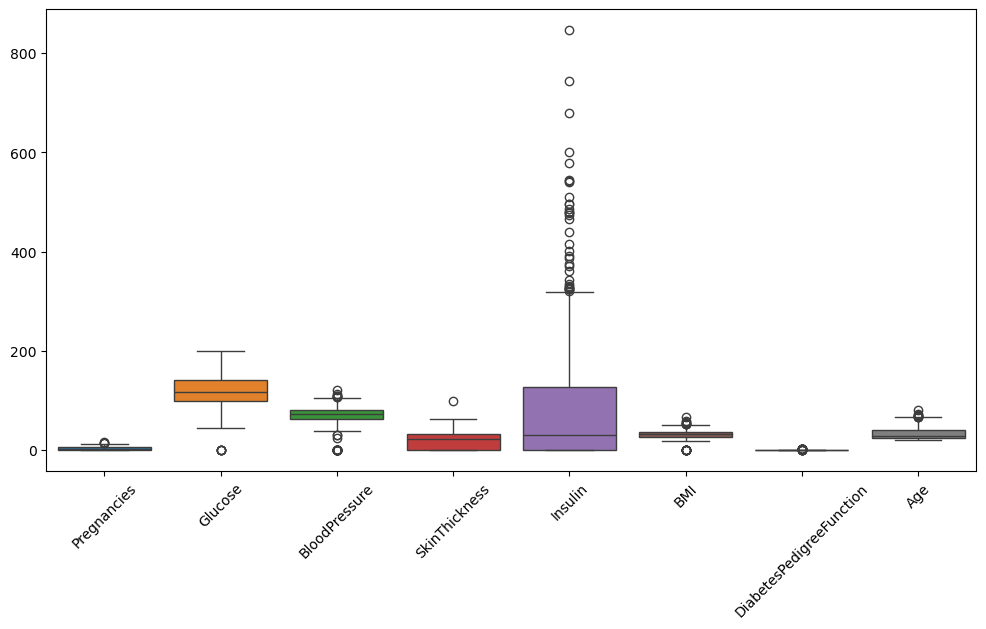

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['Outcome']))
plt.xticks(rotation=45)
plt.show()

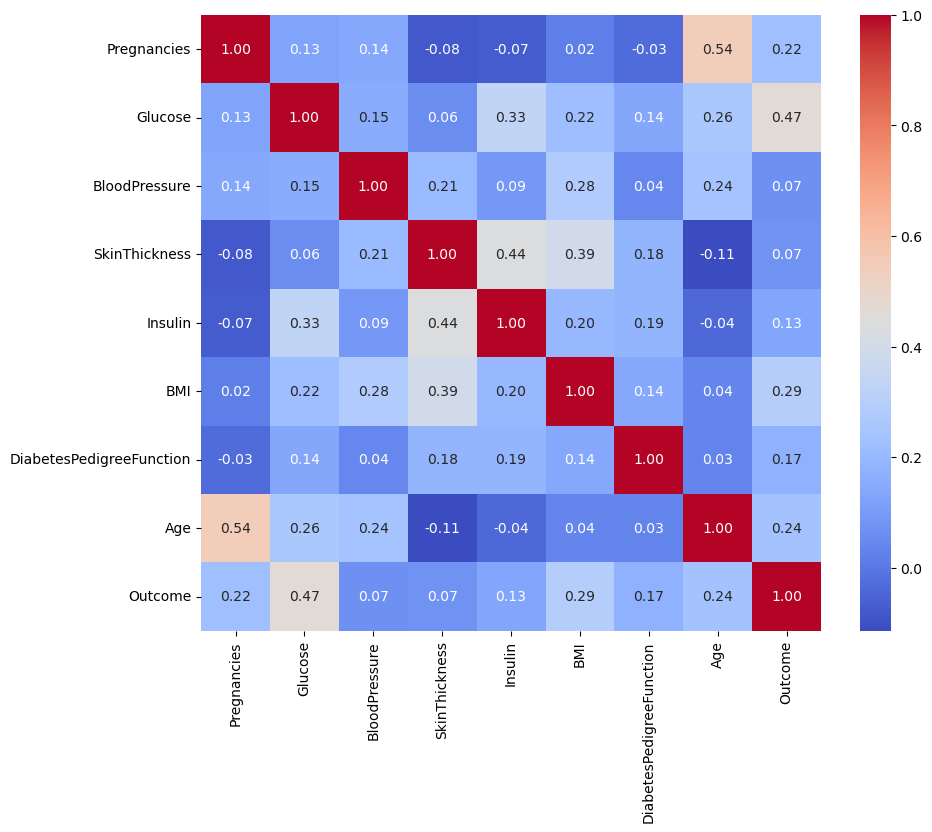

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [28]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=15)

In [31]:
sifir_degerleri = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

In [34]:
for col in sifir_degerleri:
    print(X_train[X_train[col] != 0][col].median())

117.0
72.0
29.0
129.5
32.3


In [35]:
# her kolonun kendi mediyanini bulduk bu sayede simdid buna gore dolduracaz 

In [36]:
# simdi train ve teslermizi medyanlarmiza gore dolduracam

In [40]:
median = {}
for col in sifir_degerleri:
    median_degerleri = X_train[X_train[col] != 0][col].median()
    median[col] = median_degerleri
    X_train[col] = X_train[col].replace(0,median_degerleri)

for col in sifir_degerleri:
    X_test[col] = X_test[col].replace(0,median[col])
    

In [41]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [42]:
# artik min lerde sifir goremiyorum bu duruumu duzeltmis olduk 

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train =  scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [47]:
ada = AdaBoostClassifier()
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)

In [48]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


In [49]:
# hyperparametre tuning 

In [50]:
from sklearn.model_selection import GridSearchCV

In [54]:
adabost_param = {
    'n_estimators':[50,70,120,150,200],
    'learning_rate': [0.001,0.01,0.1,1,10]
}

In [55]:
grid = GridSearchCV(estimator=AdaBoostClassifier(),param_grid=adabost_param,cv=3,verbose=1,n_jobs=-1)

In [56]:
grid.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 120, 150, 200]},
             verbose=1)

In [57]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 200}

In [62]:
grid.best_score_

np.float64(0.7671050534034752)

In [66]:
ada = AdaBoostClassifier(learning_rate = 1 , n_estimators=200)

In [67]:
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)

In [68]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.82       108
           1       0.57      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.76      0.75      0.75       154

0.7467532467532467
[[86 22]
 [17 29]]


In [70]:
# acikcasi hyper yapma cokta isimize yaramadi cokta fazla bir sey degismedi 